## Initialization

In [63]:
import cupy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
import importlib
import collision_cp
importlib.reload(collision_cp)
from collision_cp import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights, S_matrix

# parameters
e_mass = 5.48579909e-4    # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec

In [64]:
# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "RbCsRbCs"
mu = 110 / e_mass      # now in a.u.
c6 = 1.9e5         # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time
print("reduced mass", mu)
print("C6", c6)
print("beta (a0)", beta)
print("E_beta (K)", E_beta * t0)
print("tau_beta (s)", tau_beta * tau0)

reduced mass 200517.73350671504
C6 190000.0
beta (a0) 525.3927746085943
E_beta (K) 2.852507331186637e-06
tau_beta (s) 1.6824646316466855e-05


In [65]:
num_samples = 5000

# properties of resonant spectrum
rrkm = 0.25e-3     # seconds
dos = rrkm / tau0 / 2 / np.pi * E_beta
mean_spacing = 1 / dos
print(mean_spacing)

# thermal properties
temp = 0.76         # in terms of E6
num_resonances = 400        # should be odd
rrkm = 2 * np.pi / mean_spacing  # rrkm in terms of tau
print(rrkm)

0.06729858526586742
93.36281412688626


In [66]:
L = (temp / E_beta / c6) ** (1/6)
print(L) # distance (in a.u.) when energy of potential is equal to temperature
print(L / beta)

8.73042048011514
0.01661694051011475


In [67]:
length = 2 # cutoff distance (in beta)

mean_x = 1
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)
# find positive time delay

def get_spectrum():
    while True:
        energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)
        min_positive = np.min(energy_GOE_mat[energy_GOE_mat > 0])
        max_negative = np.max(energy_GOE_mat[energy_GOE_mat < 0])

        f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
        time_delay = sc.integrate.quad(f, 0, 10 * temp)[0]
        
        if time_delay > rrkm or True:
            break
    return energy_GOE_mat, W_mat, x_actual, time_delay

energy_GOE_mat, W_mat, x_actual, time_delay = get_spectrum()
print(time_delay)

88.33720137243024


C:\Users\kevin\AppData\Local\Temp\ipykernel_15012\3182606703.py:14: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  time_delay = sc.integrate.quad(f, 0, 10 * temp)[0]


In [68]:
hbar = 1
std_k = np.sqrt(temp) / 10
std_x = 1 / std_k
x0 = 100
k0 = 0.5
print(200 / (2 * k0))

def gaussian_envelope(k):
    normalization = 1 / np.sqrt((std_k * np.sqrt(2 * np.pi)))
    phase = np.exp(-1j * (k - k0) * x0)
    gaussian = np.exp(-((k - k0) / std_k) ** 2 / 4)
    return normalization * gaussian * phase

def wave(t, k, x):
    position = np.exp(1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)

def reflected_wave(t, k, x, r):
    position = np.exp(-1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return r(k) * gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)


200.0


(999,)


C:\Users\kevin\AppData\Local\Temp\ipykernel_15012\1160334201.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


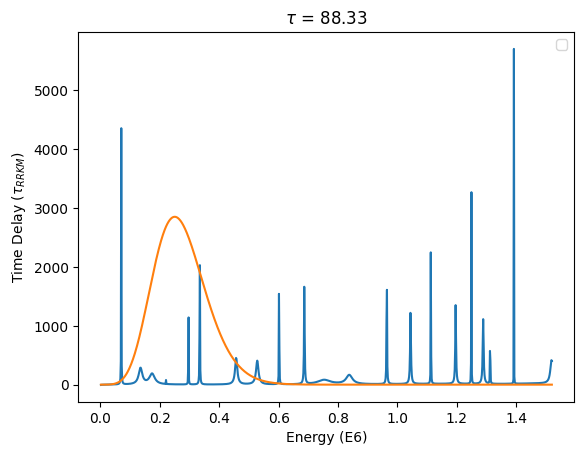

In [70]:
energy_grid = np.linspace(0, 2 * temp, 1000)[1:]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))
print(time_delays.shape)
# time_delays = (mean_spacing / 2 / np.pi) * time_delays
plt.plot(energy_grid.get(), time_delays.get())
plt.plot(energy_grid.get(), max(time_delays.get() / np.abs(gaussian_envelope(k0)).get() ** 2 / 2) * np.abs(gaussian_envelope(np.sqrt(energy_grid))).get() ** 2)
# plt.vlines(temp, min(time_delays.get()), max(time_delays.get()), colors="red", label="temperature")
plt.legend()
plt.xlabel("Energy (E6)")
plt.ylabel(r"Time Delay ($\tau_{RRKM}$)")
plt.title(r"$\tau$ = " + str(time_delay)[:5])
plt.savefig("RbCs/wavepacket/spread.pdf")
plt.show()

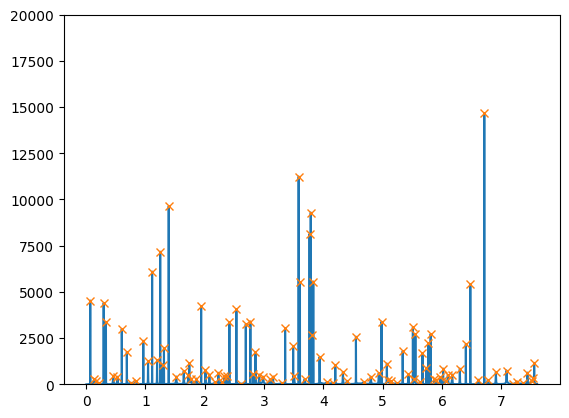

[0.06460646 0.03876388 0.04788479 0.07524752 0.0380038  0.12237224
 0.07144714 0.0729673  0.08512851 0.06688669 0.08436844 0.12617262
 0.08056806 0.06840684 0.08360836 0.05244524 0.03952395 0.02356236
 0.08056806 0.12617262 0.12693269 0.07752775 0.0159616  0.02812281
 0.09272927 0.0790479  0.07220722 0.06612661 0.10033003 0.05092509
 0.05472547 0.04788479 0.04788479 0.03572357 0.11781178 0.06992699
 0.08892889 0.07676768 0.04864486 0.03724372 0.06308631 0.06688669
 0.1140114  0.05016502 0.15505551 0.05092509 0.13529353 0.0159616
 0.07676768 0.0220422  0.07676768 0.08512851 0.01976198 0.02128213
 0.02128213 0.10641064 0.12541254 0.0950095  0.04408441 0.12845285
 0.06992699 0.14973497 0.13149315 0.11781178 0.13529353 0.04712471
 0.08892889 0.02584258 0.04940494 0.10033003 0.0919692  0.09728973
 0.07448745 0.02356236 0.01824182 0.07524752 0.04408441 0.06612661
 0.03268327 0.03952395 0.060046   0.02888289 0.07676768 0.04408441
 0.05016502 0.02964296 0.07220722 0.129973   0.10109011 0.07524

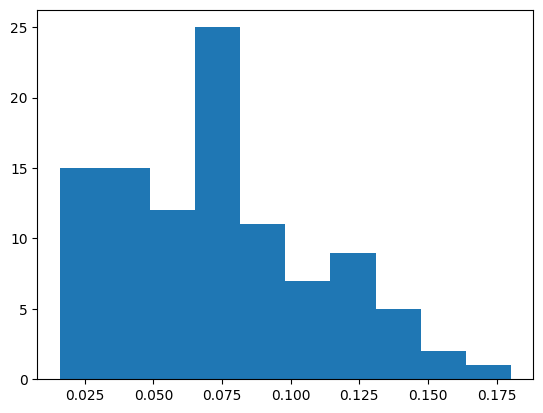

In [71]:
import scipy as sc

energy_grid = np.linspace(0, 10 * temp, 10000)[1:]
time_delays = wigner_smith_matrix(energy_grid, energy_GOE_mat, np.square(W_mat))

x = time_delays.get()

peaks, _ = sc.signal.find_peaks(x)
plt.plot(energy_grid.get(), x)
plt.plot(energy_grid.get()[peaks], x[peaks], "x")
plt.ylim([0, 20000])
plt.show()

sorted = np.sort(energy_grid[peaks])

diff = np.diff(sorted)
print(diff)
plt.hist(diff.get(), bins=10)
print(np.mean(diff))

[0.05568683 0.12677453 0.03463055 0.07662707 0.0963725  0.05382664
 0.13225077 0.01599208 0.01583367 0.04289513 0.07519879 0.12010763
 0.04285513 0.12612362 0.08336451 0.15243651 0.01726113 0.01931714
 0.08543646 0.05894115 0.05624669 0.08213542 0.03135177 0.02914429
 0.0774767  0.08286635 0.06872471 0.06504898 0.10503703 0.1229405
 0.10179879 0.07193611 0.05846228 0.05261207 0.03907575 0.0458322
 0.05012071 0.09109747 0.03121665 0.07919545 0.07088245 0.05374497
 0.0288914  0.04733145 0.03163522 0.08843918 0.07244681 0.09476807
 0.03004167 0.0544242  0.08388089 0.07275901 0.07040943 0.08113424
 0.06512461 0.09399302 0.0964888  0.04842902 0.0254168  0.17243645
 0.13687278 0.03777383 0.1037749  0.02737717 0.04509717 0.08420756
 0.02570986 0.1344319  0.08592169 0.05905418 0.03436106 0.01888975
 0.09410347 0.10286932 0.05364437 0.06329553 0.0764484  0.03173165
 0.06736523 0.04905363 0.06219002 0.00603523 0.03482174 0.00730612
 0.10168542 0.09821468 0.06650167 0.04128389 0.08967004 0.105220

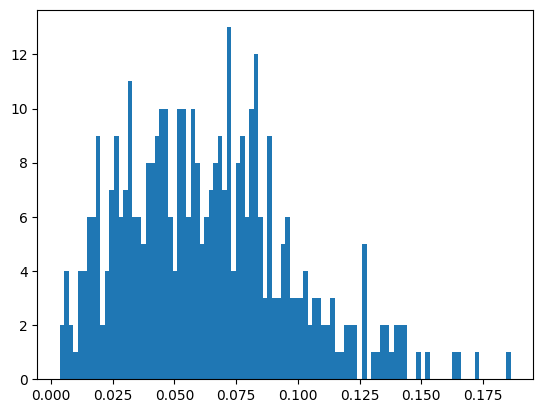

0.06362034592351659


In [62]:
print(np.diff(energy_GOE_mat)[:100])

plt.hist(np.diff(energy_GOE_mat).get(), bins=100)
plt.show()
print(np.mean(np.diff(energy_GOE_mat)))

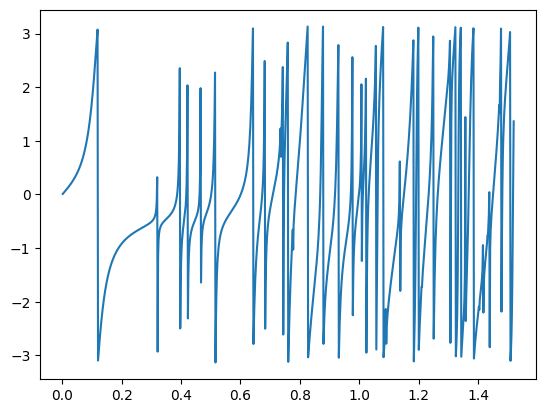

In [24]:
plt.plot(energy_grid.get(), np.angle(S_matrix((energy_grid ** 2), energy_GOE_mat, np.square(W_mat))).get())

In [72]:
xs = np.linspace(-1300, 200, 700)
dx = xs[1] - xs[0]

ps = np.linspace(k0 - 5 * std_k, k0 + 5 * std_k, 500)
dp = ps[1] - ps[0]
ps = ps.reshape((len(ps), 1))

ts = np.linspace(0, 600, 1200)
dt = ts[1] - ts[0]
print(dt)

0.5004170141784821


In [73]:
r1 = lambda k : np.exp(-1j * 2 * k * length) #* S_matrix(k ** 2, energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1))
psi1 = np.array([(np.sum(wave(t, ps, xs) + reflected_wave(t, ps, xs, r1), axis=0)) * dp for t in ts])
psi = psi1
mean1 = np.sum(np.abs(psi) ** 2 * xs, axis=1) / np.sum(np.abs(psi) ** 2, axis=1) 
mask = xs > 0
mean1_g0 = np.sum(np.abs(psi[:,mask]) ** 2 * xs[mask], axis=1) / np.sum(np.abs(psi[:,mask]) ** 2, axis=1) 

r2 = lambda k : np.exp(-1j * 2 * k * length) * np.conj(S_matrix((k ** 2), energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1)))
psi2 = np.array([(np.sum(wave(t, ps, xs) + reflected_wave(t, ps, xs, r2), axis=0)) * dp for t in ts])
psi = psi2
psi_g0 = (np.abs(psi) > 0.05)[:,mask]
mean2 = np.sum(np.abs(psi) ** 2 * xs, axis=1) / np.sum(np.abs(psi) ** 2, axis=1) 
mask = xs > 0
mean2_g0 = np.sum(np.abs(psi[:,mask]) ** 2 * xs[mask], axis=1) / np.sum(np.abs(psi[:,mask]) ** 2, axis=1) 

reflected2 = np.array([(np.sum(reflected_wave(t, ps, xs, r2), axis=0)) * dp for t in ts])

In [76]:
index = 100
print(xs[index])
print(dx)
time_min = 50
print(ts[time_min])
print(dt)

-1085.4077253218884
2.145922746781025
25.0208507089241
0.5004170141784821


In [39]:
np.sum(np.abs(reflected2[0]) ** 2 * dx)

array(0.98897686)

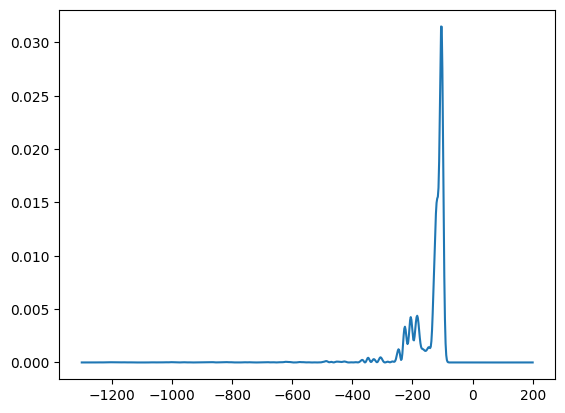

In [74]:
plt.plot(xs.get(), np.abs(reflected2[0]).get() ** 2)

C:\Users\kevin\AppData\Local\Temp\ipykernel_15012\3182606703.py:14: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  time_delay = sc.integrate.quad(f, 0, 10 * temp)[0]


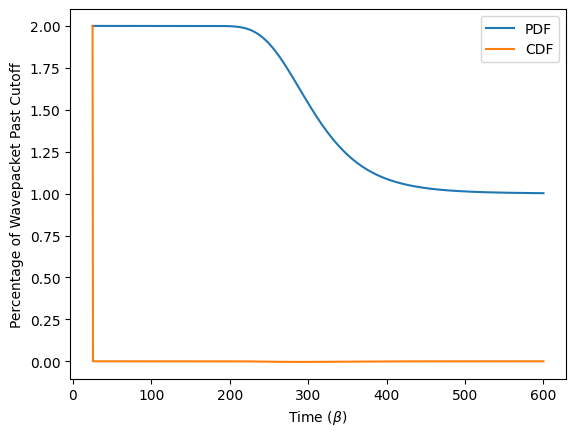

In [77]:
import pickle 

half_life = []
expected_delay = []
total_percentage = []

for i in range(1):
    energy_GOE_mat, W_mat, x_actual, time_delay = get_spectrum()

    r2 = lambda k : np.exp(-1j * 2 * k * length) * np.conj(S_matrix((k ** 2), energy_GOE_mat, np.square(W_mat)).reshape((len(k), 1)))
    psi2 = np.array([(np.sum(wave(t, ps, xs) + reflected_wave(t, ps, xs, r2), axis=0)) * dp for t in ts])

    index = 100

    flux = []

    for time_index in range(time_min, 1200):
        flux.append(np.sum(np.abs(psi1[time_index][index:]) ** 2 * dx).get())

    flux = np.array(flux)
    total_percentage.append(flux[-1])
    half_index = np.argmax(flux > 0.5) + time_min
    half_life.append(ts[half_index])

    pdf = flux.copy()
    for i in range(len(pdf) - 1, 0, -1):
        pdf[i] -= pdf[i - 1]
    expected_value = np.sum(pdf * ts[time_min:])
    expected_delay.append(expected_value) 

    plt.plot(ts[time_min:].get(), flux.get(), label="PDF")
    plt.plot(ts[time_min:].get(), pdf.get(), label="CDF")
    plt.ylabel("Percentage of Wavepacket Past Cutoff")
    plt.xlabel(r"Time ($\beta$)")
    plt.legend()
    plt.savefig("RbCs/wavepacket/flux_nores.pdf")
    plt.show()

save_dict = {"half life": half_life, "expected value": expected_delay, "percentage": total_percentage}

# with open("RbCs/wavepacket/data.pkl", "wb") as f:
#     pickle.dump(save_dict, f)

In [31]:
save_dict

{'half life': [array(203.66972477)],
 'expected value': [array(210.33537058)],
 'percentage': [array(0.99992336)]}

In [32]:
import pickle 
with open("RbCs/wavepacket/data.pkl", "rb") as f:
    data = pickle.load(f)
print(data)

{'half life': [array(138.11509591), array(168.64053378), array(175.14595496), array(156.13010842), array(181.65137615), array(122.60216847), array(137.6146789), array(189.15763136), array(167.13928274), array(182.65221018), array(137.6146789), array(178.64887406), array(204.17014178), array(133.11092577), array(170.14178482), array(136.11342786), array(141.61801501), array(140.11676397), array(173.14428691), array(179.14929108), array(185.15429525), array(141.117598), array(172.64386989), array(154.12844037), array(143.11926606), array(138.11509591), array(140.61718098), array(142.11843203), array(151.6263553), array(126.60550459), array(161.13427857), array(132.11009174), array(152.62718932), array(135.61301084), array(166.13844871), array(153.12760634), array(137.6146789), array(167.63969975), array(150.62552127), array(180.65054212), array(125.60467056), array(134.61217681), array(122.60216847), array(151.6263553), array(155.62969141), array(135.61301084), array(145.62135113), array

Half Life 150.30325271059215
Expected 169.71971266818997
RRKM 93.36281412688626


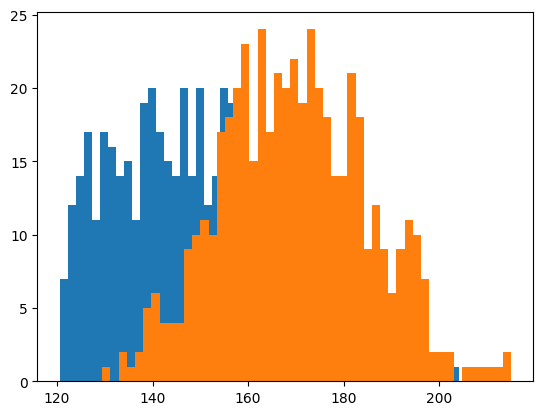

In [17]:
half_life = np.array(data["half life"])
expected_delay = np.array(data["expected value"])
total_percentage = data["percentage"]

print("Half Life", np.mean(half_life))
plt.hist(half_life.get(), bins=50)

print("Expected", np.mean(expected_delay))
plt.hist(expected_delay.get(), bins=50)

print("RRKM", rrkm)

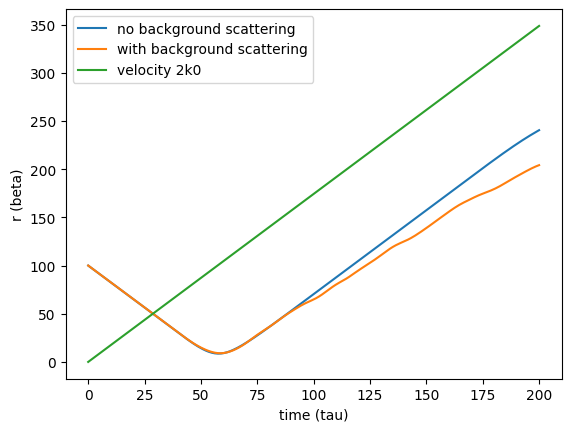

AssertionError: 

In [11]:
from scipy.interpolate import UnivariateSpline

tsnp = ts.get()

plt.plot(tsnp, mean1_g0.get(), label='no background scattering')
plt.plot(tsnp, mean2_g0.get(), label='with background scattering')
plt.plot(tsnp, 2 * tsnp * k0.get(), label='velocity 2k0')
plt.xlabel('time (tau)')
plt.ylabel('r (beta)')
plt.legend()


plt.savefig('./wavepackets/background.pdf')
plt.show()

points = np.arange(11, 120, 1).get()
delays = []
start = 100
for point in points:
    spl1 = UnivariateSpline(tsnp[start:], (mean1_g0[start:] - point).get(), s=0)
    spl2 = UnivariateSpline(tsnp[start:], (mean2_g0[start:] - point).get(), s=0)
    assert(len(spl1.roots()) == 1)
    assert(len(spl2.roots()) == 1)
    r1 = spl1.roots()[0]
    r2 = spl2.roots()[0]
    delays.append(r2 - r1)


plt.plot(points, delays)
plt.show()
print(max(delays))

In [ ]:
(np.pi * 2 ** (-3/2) / math.gamma(5/4) / math.gamma(1/2)) ** 2
print(abar / k0)

0.628932628271217


## Together

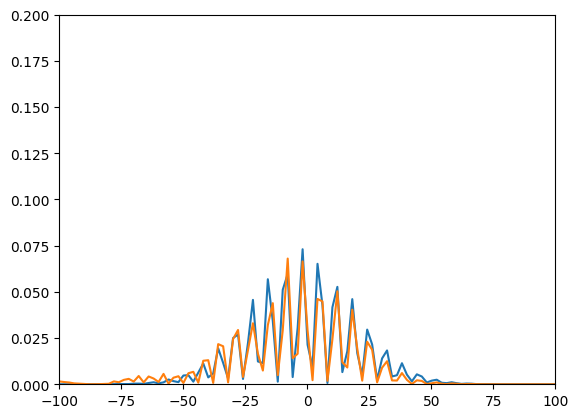

In [33]:
psis = [psi1, psi2]

import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots()
lines = []
for psi in psis:
    line = ax.plot(xs.get(), np.abs(psi[i]).get() ** 2)[0]
    lines.append(line)
ax.set(xlim=[-100, 100], ylim=[0, 0.2])

num = 1000
# line2 = ax.plot([mean1[0] for i in range(num)], [i / num for i in range(num)], color='red')[0]
# line3 = ax.plot([mean1_g0[0] for i in range(num)], [i / num for i in range(num)], color='green')[0]

def update(frame):
    global i
    # update the line plot:
    i += 10
    for j in range(len(psis)):
        lines[j].set_ydata(np.abs(psis[j][i]).get() ** 2)
    # line2.set_xdata([mean1[i] for j in range(num)])
    # line3.set_xdata([mean1_g0[i] for j in range(num)])
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=20, interval=30)
ani

## Animation 2

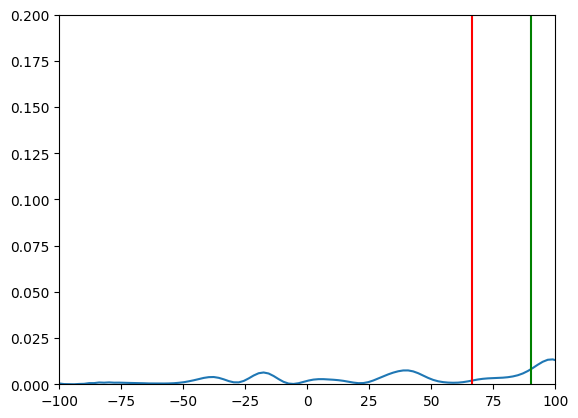

In [287]:
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots()
line = ax.plot(xs.get(), np.abs(psi2[i]).get() ** 2)[0]
ax.set(xlim=[-100, 100], ylim=[0, 0.2])

num = 1000
line2 = ax.plot([mean2[0].get() for i in range(num)], [i / num for i in range(num)], color='red')[0]
line3 = ax.plot([mean2_g0[0].get() for i in range(num)], [i / num for i in range(num)], color='green')[0]

def update(frame):
    global i
    # update the line plot:
    i += 10
    line.set_ydata(np.abs(psi2[i]).get() ** 2)
    line2.set_xdata([mean2[i].get() for j in range(num)])
    line3.set_xdata([mean2_g0[i].get() for j in range(num)])
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=25, interval=30)
ani

## Animation 1

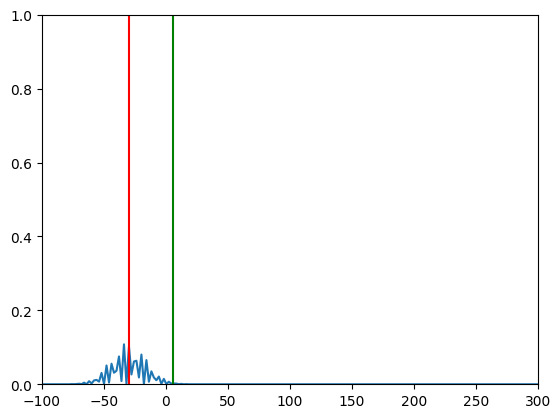

In [274]:
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots()
line = ax.plot(xs.get(), np.abs(psi1[i]).get() ** 2)[0]
ax.set(xlim=[-100, 300], ylim=[0, 1])

num = 1000
line2 = ax.plot([mean1[0].get() for i in range(num)], [i / num for i in range(num)], color='red')[0]
line3 = ax.plot([mean1_g0[0].get() for i in range(num)], [i / num for i in range(num)], color='green')[0]

def update(frame):
    global i
    # update the line plot:
    i += 10
    line.set_ydata(np.abs(psi1[i]).get() ** 2)
    line2.set_xdata([mean1[i].get() for j in range(num)])
    line3.set_xdata([mean1_g0[i].get() for j in range(num)])
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=20, interval=30)
ani